# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 1. modell **ResNet50** modell teljes tanítással történő tesztelése

#### A  ResNet50 modell tesztelése 1k, 5k, 10k, 25k tanítás után a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).

---

✅ 3. FÁZIS: ResNet50 – Few-shot fine-tune

🎯 Cél:
Megvizsgálni, hogyan változik a ResNet50 teljesítménye különböző mennyiségű adat esetén.

✅ 1. Telepítés, import, GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import random, os, time
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("💻 Eszköz:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 191.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 218.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 179.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 166.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 214.6 MB/s eta 0:00:00
💻 Eszköz: cuda


✅ 2. Drive csatolása és adatbázis kicsomagolása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok elérhetők:", extract_path)


Mounted at /content/drive
✅ Adatok elérhetők: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok előkészítése és részhalmaz kiválasztása

In [ ]:
from collections import defaultdict

# Képek transzformációja
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Teljes train / val / test betöltése
train_dataset_full = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

# Stratifikált részhalmaz létrehozása
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    class_counts = {cls: len(indices) for cls, indices in class_indices.items()}
    total_classes = len(class_counts)

    per_class = total_images // total_classes
    selected_indices = []

    for cls, indices in class_indices.items():
        selected = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(selected)

    print(f"📦 Részhalmaz méret: {len(selected_indices)} kép")
    return Subset(dataset, selected_indices)

# Részhalmazok generálása
subset_sizes = [1000, 5000, 10000, 25000]
subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset_full.classes
num_classes = len(class_names)


📦 Részhalmaz méret: 912 kép
📦 Részhalmaz méret: 4902 kép
📦 Részhalmaz méret: 9918 kép
📦 Részhalmaz méret: 24966 kép


✅ 4. Függvény: Modell betöltése (ResNet50, új output réteggel)

In [ ]:
def get_resnet50_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


✅ 5. Függvény: Tanítás adott részhalmazon

In [ ]:
def train_on_subset(train_dataset, subset_name, num_epochs=10):
    print(f"\n🚀 Tanítás: {subset_name} képes részhalmaz")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    model = get_resnet50_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Val
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


✅ 🔹 BLOKK 1 – 1k képes tanítóhalmaz


🚀 Tanítás: 1k képes részhalmaz


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]
Epoch 1/10 - train: 100%|██████████| 15/15 [00:06<00:00,  2.15it/s]


📊 Epoch 1: Train loss=4.7268, acc=0.0143 | Val loss=4.6176, acc=0.0545


Epoch 2/10 - train: 100%|██████████| 15/15 [00:04<00:00,  3.13it/s]


📊 Epoch 2: Train loss=4.2507, acc=0.4265 | Val loss=4.3277, acc=0.1355


...

📊 Epoch 8: Train loss=0.7962, acc=0.9792 | Val loss=2.8046, acc=0.3179


Epoch 9/10 - train: 100%|██████████| 15/15 [00:04<00:00,  3.08it/s]


📊 Epoch 9: Train loss=0.5309, acc=0.9912 | Val loss=2.7045, acc=0.3295


Epoch 10/10 - train: 100%|██████████| 15/15 [00:04<00:00,  3.07it/s]


📊 Epoch 10: Train loss=0.3352, acc=0.9967 | Val loss=2.7344, acc=0.3036


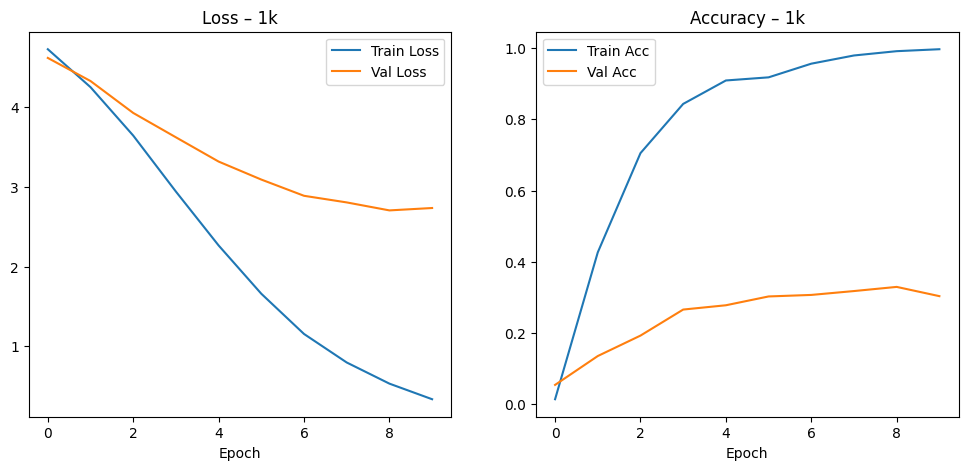


🔍 Metrikák – ResNet50 trained on 1k:
✅ Top-1 Accuracy:  0.3022
✅ Top-5 Accuracy:  0.6505
🎯 Precision:       0.2851
🎯 Recall:          0.3149
🎯 F1-score:        0.2820
⏱️ Inference time:  31.49 sec


In [ ]:
# 🔧 Tanítás 1k halmazon
model_1k, train_loss_1k, val_loss_1k, train_acc_1k, val_acc_1k = train_on_subset(subsets["1000"], "1k", num_epochs=10)

# 📉 Tanulási görbe – 1k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1k, label="Train Loss")
plt.plot(val_loss_1k, label="Val Loss")
plt.title("Loss – 1k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_1k, label="Train Acc")
plt.plot(val_acc_1k, label="Val Acc")
plt.title("Accuracy – 1k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 🧪 Tesztelés 1k modellen
model_1k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

from sklearn.metrics import *
print("\n🔍 Metrikák – ResNet50 trained on 1k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


✅ 🔹 BLOKK 2 – 5k képes tanítóhalmaz


🚀 Tanítás: 5k képes részhalmaz


Epoch 1/10 - train: 100%|██████████| 77/77 [00:25<00:00,  3.07it/s]


📊 Epoch 1: Train loss=4.2541, acc=0.1336 | Val loss=2.9191, acc=0.3120


Epoch 2/10 - train: 100%|██████████| 77/77 [00:25<00:00,  3.08it/s]


📊 Epoch 2: Train loss=2.4980, acc=0.4419 | Val loss=2.2629, acc=0.4149


...

📊 Epoch 8: Train loss=0.0653, acc=0.9955 | Val loss=2.1871, acc=0.4492


Epoch 9/10 - train: 100%|██████████| 77/77 [00:25<00:00,  3.07it/s]


📊 Epoch 9: Train loss=0.0356, acc=0.9988 | Val loss=2.2443, acc=0.4525


Epoch 10/10 - train: 100%|██████████| 77/77 [00:25<00:00,  3.08it/s]


📊 Epoch 10: Train loss=0.0250, acc=0.9992 | Val loss=2.2541, acc=0.4598


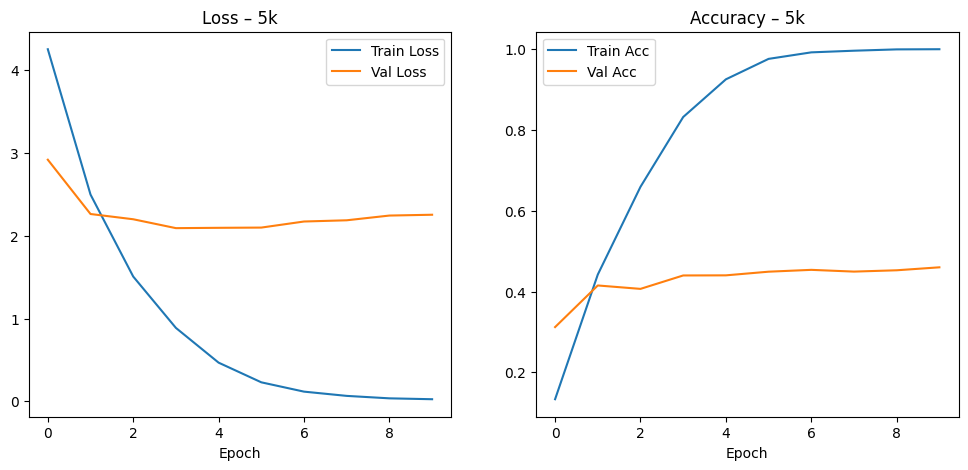


🔍 Metrikák – ResNet50 trained on 5k:
✅ Top-1 Accuracy:  0.4603
✅ Top-5 Accuracy:  0.7766
🎯 Precision:       0.4254
🎯 Recall:          0.4762
🎯 F1-score:        0.4325
⏱️ Inference time:  31.72 sec


In [ ]:
model_5k, train_loss_5k, val_loss_5k, train_acc_5k, val_acc_5k = train_on_subset(subsets["5000"], "5k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_5k, label="Train Loss")
plt.plot(val_loss_5k, label="Val Loss")
plt.title("Loss – 5k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_5k, label="Train Acc")
plt.plot(val_acc_5k, label="Val Acc")
plt.title("Accuracy – 5k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_5k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_5k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ResNet50 trained on 5k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


✅ 🔹 BLOKK 3 – 10k képes tanítóhalmaz


🚀 Tanítás: 10k képes részhalmaz


Epoch 1/10 - train: 100%|██████████| 155/155 [00:49<00:00,  3.11it/s]


📊 Epoch 1: Train loss=3.4771, acc=0.2365 | Val loss=2.1774, acc=0.4217


Epoch 2/10 - train: 100%|██████████| 155/155 [00:50<00:00,  3.09it/s]


📊 Epoch 2: Train loss=1.7880, acc=0.5453 | Val loss=1.9495, acc=0.4846


...

📊 Epoch 8: Train loss=0.0397, acc=0.9944 | Val loss=2.0952, acc=0.5121


Epoch 9/10 - train: 100%|██████████| 155/155 [00:50<00:00,  3.08it/s]


📊 Epoch 9: Train loss=0.0341, acc=0.9955 | Val loss=2.1724, acc=0.5068


Epoch 10/10 - train: 100%|██████████| 155/155 [00:50<00:00,  3.08it/s]


📊 Epoch 10: Train loss=0.0270, acc=0.9958 | Val loss=2.2414, acc=0.5073


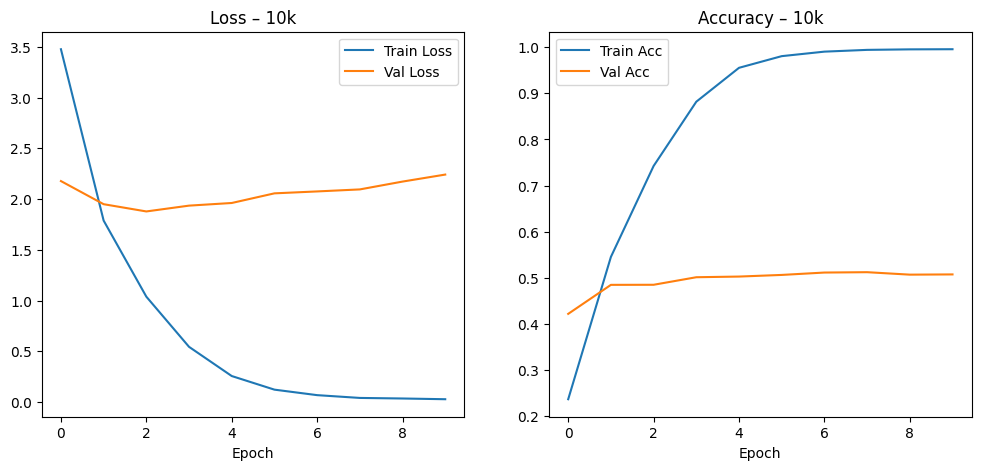


🔍 Metrikák – ResNet50 trained on 10k:
✅ Top-1 Accuracy:  0.5133
✅ Top-5 Accuracy:  0.8177
🎯 Precision:       0.4782
🎯 Recall:          0.5421
🎯 F1-score:        0.4905
⏱️ Inference time:  31.71 sec


In [ ]:
model_10k, train_loss_10k, val_loss_10k, train_acc_10k, val_acc_10k = train_on_subset(subsets["10000"], "10k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_10k, label="Train Loss")
plt.plot(val_loss_10k, label="Val Loss")
plt.title("Loss – 10k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_10k, label="Train Acc")
plt.plot(val_acc_10k, label="Val Acc")
plt.title("Accuracy – 10k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_10k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_10k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ResNet50 trained on 10k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


✅ 🔹 BLOKK 4 – 25k képes tanítóhalmaz


🚀 Tanítás: 25k képes részhalmaz


Epoch 1/10 - train: 100%|██████████| 391/391 [02:06<00:00,  3.09it/s]


📊 Epoch 1: Train loss=2.6502, acc=0.3688 | Val loss=1.8348, acc=0.4948


Epoch 2/10 - train: 100%|██████████| 391/391 [02:06<00:00,  3.09it/s]


📊 Epoch 2: Train loss=1.3594, acc=0.6291 | Val loss=1.6443, acc=0.5419


...

📊 Epoch 8: Train loss=0.0847, acc=0.9807 | Val loss=2.1345, acc=0.5412


Epoch 9/10 - train: 100%|██████████| 391/391 [02:06<00:00,  3.09it/s]


📊 Epoch 9: Train loss=0.0809, acc=0.9809 | Val loss=2.2254, acc=0.5494


Epoch 10/10 - train: 100%|██████████| 391/391 [02:06<00:00,  3.09it/s]


📊 Epoch 10: Train loss=0.0738, acc=0.9821 | Val loss=2.2810, acc=0.5423


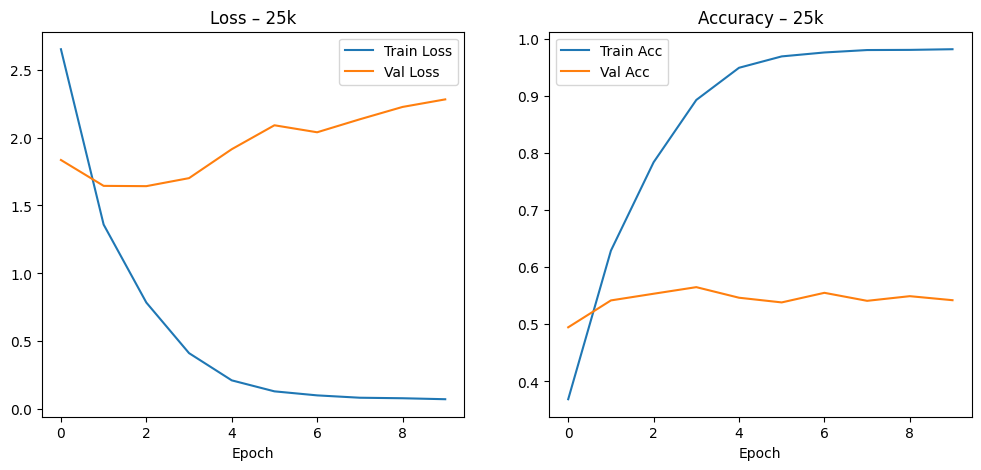


🔍 Metrikák – ResNet50 trained on 25k:
✅ Top-1 Accuracy:  0.5499
✅ Top-5 Accuracy:  0.8376
🎯 Precision:       0.5310
🎯 Recall:          0.5978
🎯 F1-score:        0.5436
⏱️ Inference time:  31.82 sec


In [ ]:
model_25k, train_loss_25k, val_loss_25k, train_acc_25k, val_acc_25k = train_on_subset(subsets["25000"], "25k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_25k, label="Train Loss")
plt.plot(val_loss_25k, label="Val Loss")
plt.title("Loss – 25k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_25k, label="Train Acc")
plt.plot(val_acc_25k, label="Val Acc")
plt.title("Accuracy – 25k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_25k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_25k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ResNet50 trained on 25k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


✅ 1. Összevont Accuracy és Loss grafikonok

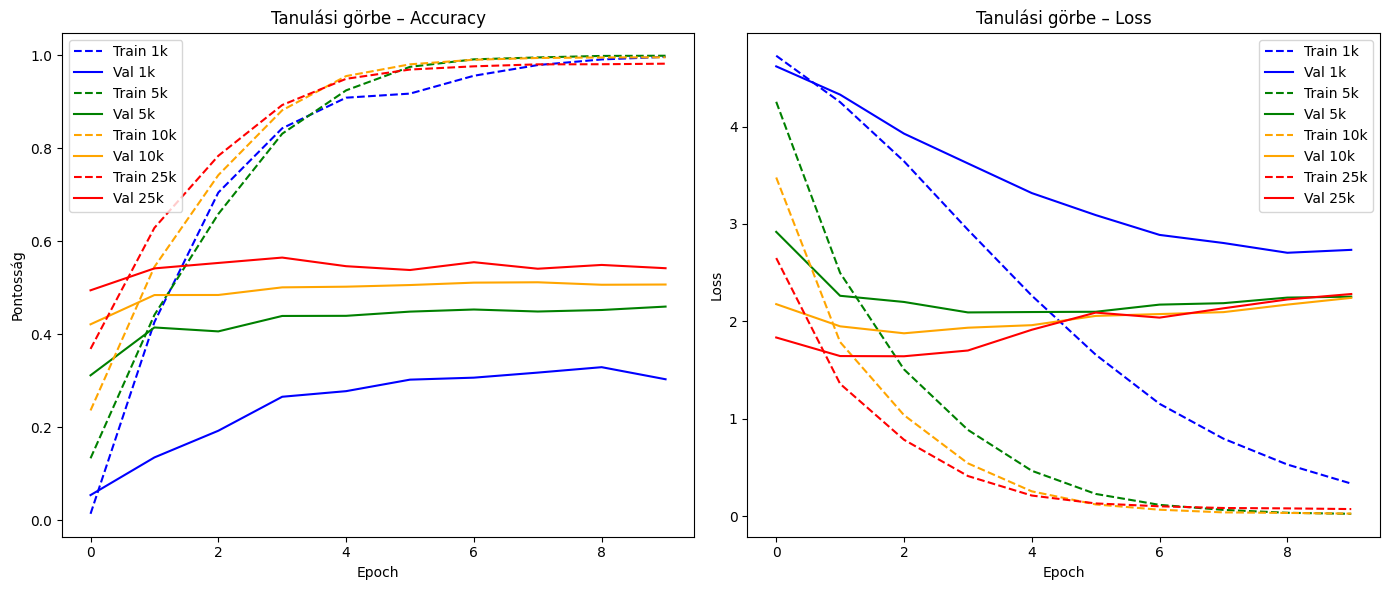

In [ ]:
plt.figure(figsize=(14, 6))

# Accuracy összevetés
plt.subplot(1, 2, 1)
plt.plot(train_acc_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_acc_1k,   label="Val 1k",   color='blue')
plt.plot(train_acc_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_acc_5k,   label="Val 5k",   color='green')
plt.plot(train_acc_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_acc_10k,   label="Val 10k",   color='orange')
plt.plot(train_acc_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_acc_25k,   label="Val 25k",   color='red')
plt.title("Tanulási görbe – Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()

# Loss összevetés
plt.subplot(1, 2, 2)
plt.plot(train_loss_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_loss_1k,   label="Val 1k",   color='blue')
plt.plot(train_loss_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_loss_5k,   label="Val 5k",   color='green')
plt.plot(train_loss_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_loss_10k,   label="Val 10k",   color='orange')
plt.plot(train_loss_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_loss_25k,   label="Val 25k",   color='red')
plt.title("Tanulási görbe – Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


✅ 2. Mini Confusion Matrix összevetés (4 mátrix 1 ábrán)

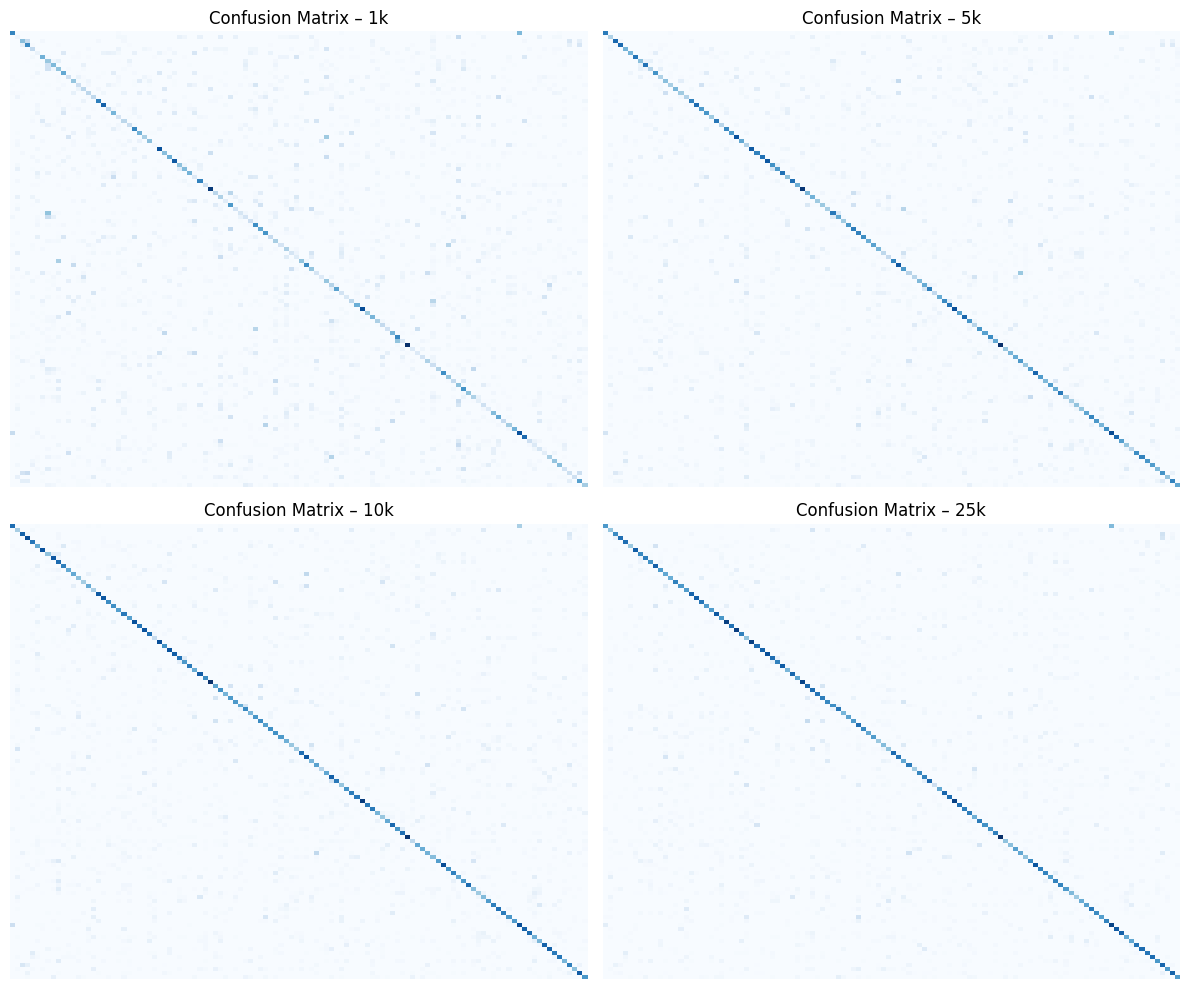

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_mini_confmat(model, title):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, cbar=False, xticklabels=False, yticklabels=False, cmap="Blues")

plt.figure(figsize=(12, 10))
for i, (model, title) in enumerate(zip(
    [model_1k, model_5k, model_10k, model_25k],
    ["1k", "5k", "10k", "25k"]
)):
    plt.subplot(2, 2, i+1)
    plot_mini_confmat(model, title)
    plt.title(f"Confusion Matrix – {title}")

plt.tight_layout()
plt.show()
